Import Libraries

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

Load Datasets

In [12]:
df=pd.read_csv(r"C:\Users\User\Documents\GitHub\My_Ai_Course\Final Assessment\1.Machine Learning Datasets\Space industery Analytics\Space_Industry_Analytics_2010_2024.csv")
df

,Company,Year,Launches,Successful,Failed,Revenue_USD_M,Budget_Funding_USD_M,Employees,Rockets,Success_Rate_%
0,SpaceX,2010,2,2,0,80,150,1100,1,100.00
1,SpaceX,2011,0,0,0,180,200,1800,1,0.00
2,SpaceX,2012,2,2,0,300,400,2500,1,100.00
3,SpaceX,2013,3,3,0,500,500,3000,2,100.00
4,SpaceX,2014,6,6,0,1000,600,4000,2,100.00
5,SpaceX,2015,7,6,1,1300,1000,5000,2,85.71
6,SpaceX,2016,9,8,1,1600,1200,6000,2,88.89
7,SpaceX,2017,18,18,0,2200,1500,7000,3,100.00
8,SpaceX,2018,21,21,0,2900,2000,8000,3,100.00
9,SpaceX,2019,13,13,0,1450,2500,9000,3,100.00


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Company               45 non-null     str    
 1   Year                  45 non-null     int64  
 2   Launches              45 non-null     int64  
 3   Successful            45 non-null     int64  
 4   Failed                45 non-null     int64  
 5   Revenue_USD_M         45 non-null     int64  
 6   Budget_Funding_USD_M  45 non-null     int64  
 7   Employees             45 non-null     int64  
 8   Rockets               45 non-null     int64  
 9   Success_Rate_%        45 non-null     float64
dtypes: float64(1), int64(8), str(1)
memory usage: 3.6 KB


In [14]:
df.describe()

,Year,Launches,Successful,Failed,Revenue_USD_M,Budget_Funding_USD_M,Employees,Rockets,Success_Rate_%
count,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000
mean,2017.000000,13.288889,13.200000,0.088889,1046.288889,7768.222222,8768.955556,2.111111,78.694889
std,4.369314,25.074092,25.105776,0.287799,2519.076857,9417.102189,7835.731778,1.265310,40.173679
min,2010.000000,0.000000,0.000000,0.000000,0.000000,1.000000,5.000000,0.000000,0.000000
25%,2013.000000,3.000000,2.000000,0.000000,0.000000,150.000000,900.000000,1.000000,88.890000
50%,2017.000000,7.000000,6.000000,0.000000,1.000000,1800.000000,7000.000000,2.000000,100.000000
75%,2021.000000,10.000000,10.000000,0.000000,500.000000,18010.000000,17500.000000,3.000000,100.000000
max,2024.000000,134.000000,134.000000,1.000000,13100.000000,25400.000000,19000.000000,5.000000,100.000000


In [15]:
df.shape

(45, 10)

Missing Values

In [16]:
df.isnull().sum()

Company                 0
Year                    0
Launches                0
Successful              0
Failed                  0
Revenue_USD_M           0
Budget_Funding_USD_M    0
Employees               0
Rockets                 0
Success_Rate_%          0
dtype: int64

Company Distribution

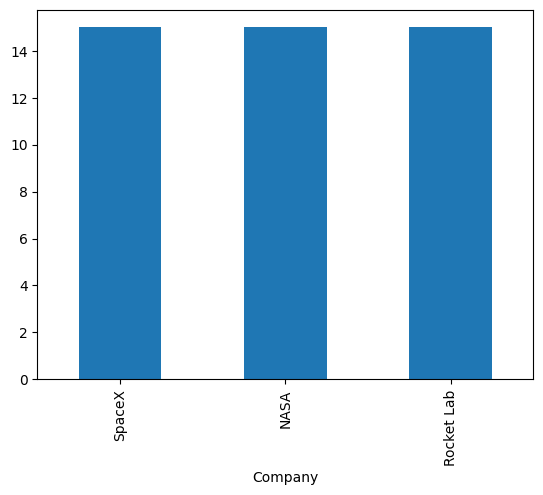

In [17]:
df['Company'].value_counts().plot(kind='bar')
plt.show()

Launches Trend

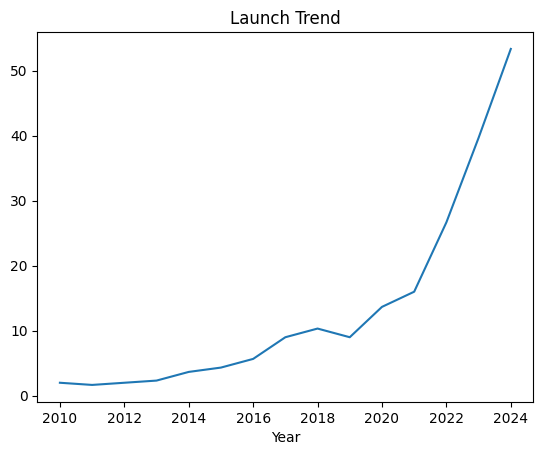

In [18]:
df.groupby('Year')['Launches'].mean().plot()
plt.title("Launch Trend")
plt.show()

Correlation Heatmap

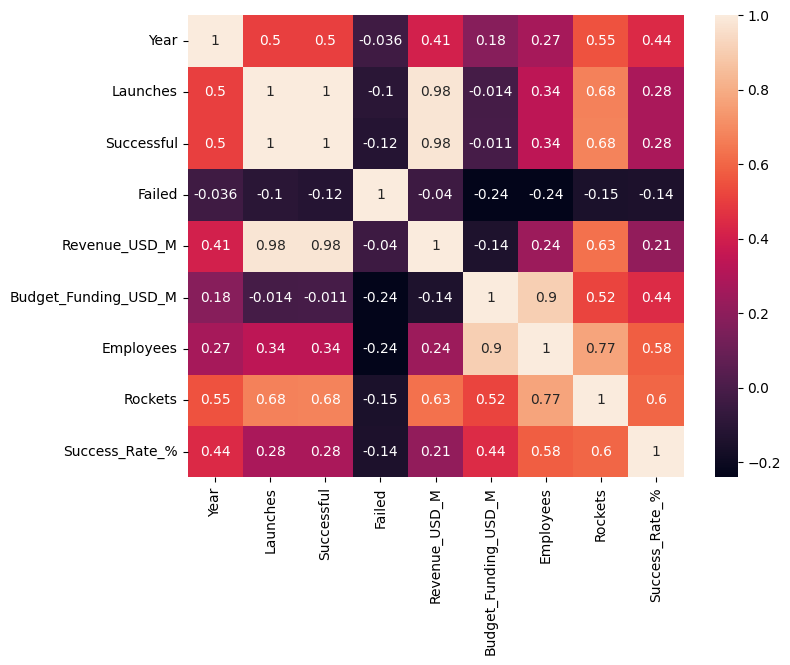

In [19]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

Classification Model

In [20]:
X = df[['Launches','Successful','Failed','Revenue_USD_M','Employees']]
y = df['Company']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
model = RandomForestClassifier()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test,y_pred))

Accuracy: 1.0


Regression Model

In [21]:
X = df[['Launches','Successful','Employees','Rockets']]
y = df['Revenue_USD_M']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
model = LinearRegression()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
print("MSE:", mean_squared_error(y_test,y_pred))

MSE: 322534.4450371016


Clustering

In [22]:

X = df[['Launches','Revenue_USD_M','Employees']]

kmeans = KMeans(n_clusters=3)
df['Cluster'] = kmeans.fit_predict(X)
df[['Company','Cluster']].head()

,Company,Cluster
0,SpaceX,1
1,SpaceX,1
2,SpaceX,1
3,SpaceX,1
4,SpaceX,1


Ensemble Learning

In [23]:
X = df[['Launches','Successful','Employees']]
y = df['Revenue_USD_M']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
rf = RandomForestRegressor()
rf.fit(X_train,y_train)
gb = GradientBoostingRegressor()
gb.fit(X_train,y_train)
print("Models Trained Successfully")

Models Trained Successfully


Feature Importance

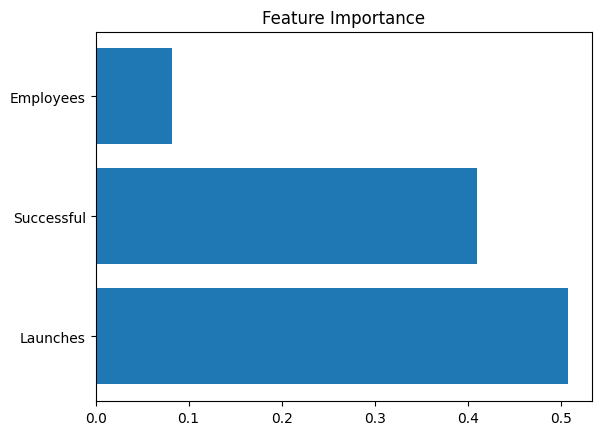

In [25]:
importances = rf.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()